# Explore here

In [3]:
!pip install missingno MissForest
!pip install lightgbm
!pip install tqdm
!pip install statsmodels
!pip install shap

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.1.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.1.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.1.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.1.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.1.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import missingno as msno
from sklearn.model_selection import train_test_split
from missforest import MissForest
from sklearn.ensemble import IsolationForest
from sklearn.ensemble import RandomForestRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor
import shap
import lightgbm as lgb
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_absolute_percentage_error

## Nos contectamos con la data y la convertimos a DF

In [3]:
df = pd.read_csv('/workspaces/jovegom-intro-ml/data/raw/arbnbdataset.csv',index_col="id")
pd.set_option('display.max_columns', None) # mostramos todas las columnas
df


,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
id,,,,,,,,,,,,,,,
2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27


## Valores Unicos

In [6]:
unicos = df.nunique()
unicos


name                              47905
host_id                           37457
host_name                         11452
neighbourhood_group                   5
neighbourhood                       221
latitude                          19048
longitude                         14718
room_type                             3
price                               674
minimum_nights                      109
number_of_reviews                   394
last_review                        1764
reviews_per_month                   937
calculated_host_listings_count       47
availability_365                    366
dtype: int64

No tienemos ninguna columna que tenga valores unicos

## Eliminamos columnas redundantes

In [7]:
df.drop('host_name' , axis=1, inplace=True) # Se elimina esta columna ya que es redundate con Host name y necesitamos varibles numericas
df.drop('name', axis=1, inplace=True) #Se elimina esta columna ya que no aporta ninguna categoria a los datos

## Eliminamos filas y columnas duplicadas

In [4]:
# Filas
df.duplicated().sum()

np.int64(0)

In [5]:
# Columnas
df.T.duplicated().sum()


np.int64(0)

No tenemos columnas y filas duplicadas

## Valores faltantes

In [9]:
faltantes = df.isna().mean()*100
faltantes[faltantes>0]

last_review          20.558339
reviews_per_month    20.558339
dtype: float64

<Axes: >

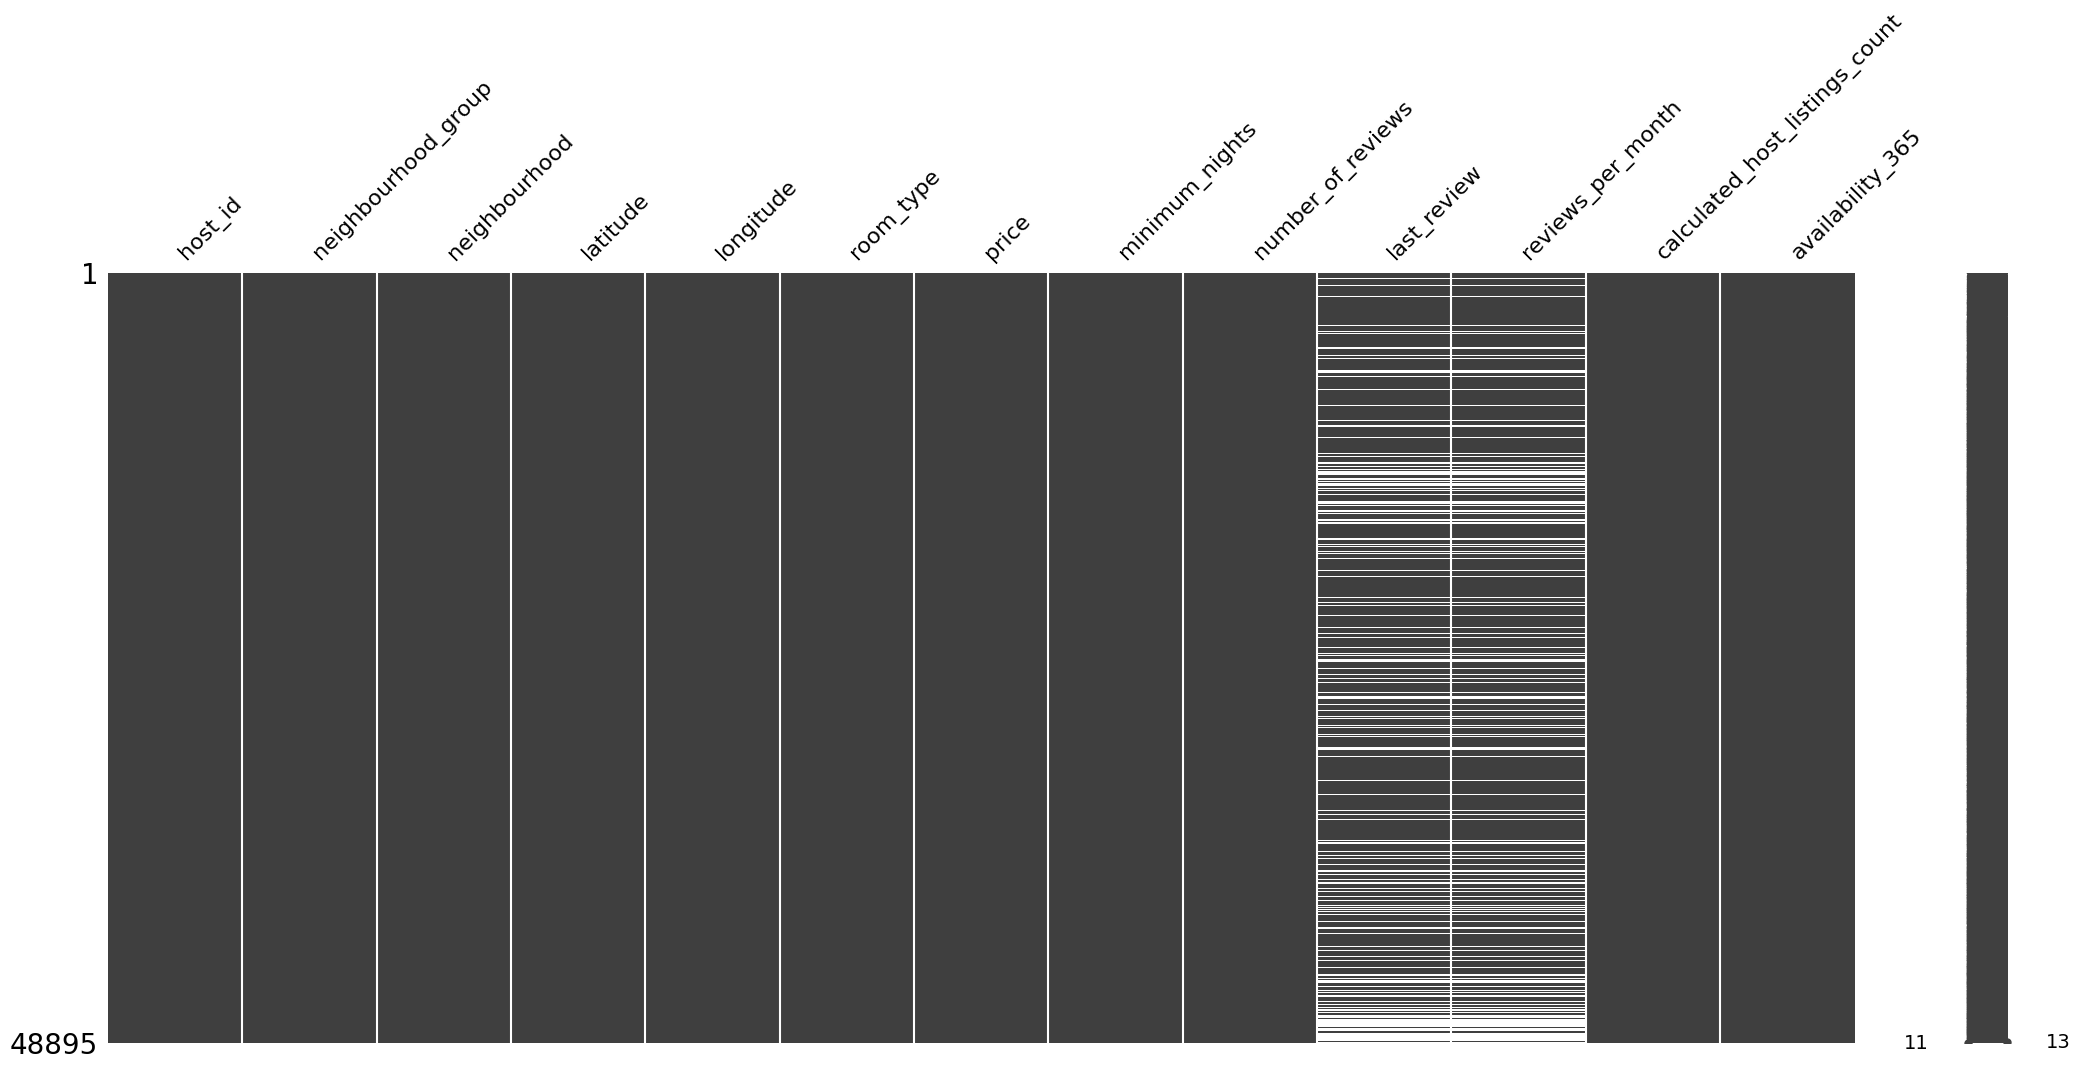

In [10]:
msno.matrix(df)

## Imputar

### Reviews_per_month y last_review    

al analizar la grafica anterior podemos observar que los faltantes son los mismos en ambas variables, y se intuye que esto es debido a que los airbnb son nuevos por ende no tienen reviews.

In [11]:
# Guardamos un Df con los valores que vamos a cambiar en caso de que lo queramos ver en un futuro
df_original=df[['last_review','neighbourhood','neighbourhood_group','room_type',]]
# Creamos una columna binaria 0 si es vivienda nueva y 1 si no
df['new'] = df['last_review'].map(lambda x: 1 if pd.notna(x) and x != '' else 0) 
# Eliminamos la columna original
df.drop('last_review', axis=1, inplace=True) 
# Remplazamos por 0 los valores Nan en number_of_reviews
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

## Codificar variables categóricas.

In [12]:
encoder = LabelEncoder()
df['neighbourhood'] = encoder.fit_transform(df['neighbourhood'])
df['neighbourhood_group'] = encoder.fit_transform(df['neighbourhood_group'])
df['room_type'] = encoder.fit_transform(df['room_type'])


## Train test split

In [13]:
X= df.drop('price',axis=1)
y= df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Outliers

In [14]:
pd.set_option('display.float_format', '{:.3f}'.format)
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
host_id,39116.000,67593557.435,78670917.793,2438.000,7812757.750,30598307.500,107434423.000,274321313.000
neighbourhood_group,39116.000,1.674,0.734,0.000,1.000,2.000,2.000,4.000
neighbourhood,39116.000,107.303,68.727,0.000,51.000,94.000,178.000,220.000
latitude,39116.000,40.729,0.055,40.500,40.690,40.723,40.763,40.913
longitude,39116.000,-73.952,0.046,-74.243,-73.983,-73.956,-73.936,-73.713
room_type,39116.000,0.502,0.545,0.000,0.000,0.000,1.000,2.000
minimum_nights,39116.000,7.145,21.473,1.000,1.000,3.000,5.000,1250.000
number_of_reviews,39116.000,23.335,44.499,0.000,1.000,5.000,24.000,629.000
reviews_per_month,39116.000,1.094,1.604,0.000,0.040,0.370,1.590,58.500
calculated_host_listings_count,39116.000,7.189,33.173,1.000,1.000,1.000,2.000,327.000


In [15]:
iso = IsolationForest(random_state=123)
df_num = X_train.copy()
df_num['outlier_flag'] = iso.fit_predict(X_train)
df_num['outlier_flag'].value_counts()

outlier_flag
 1    33134
-1     5982
Name: count, dtype: int64

## Método 1 Feature importance de RF

In [16]:
# Entrenamiento de RF
model = RandomForestRegressor(random_state=42,n_jobs=-1).fit(X_train, y_train)
# Importancia de características
importances = model.feature_importances_/model.feature_importances_.sum()*100
# Convertir a DataFrame
df_rf_imp = pd.DataFrame({'feature': X_train.columns,'rf_importance': importances}).sort_values(by='rf_importance', ascending=False)
# Calculamos la importancia acumulada
df_rf_imp['rf_importance_acum'] = df_rf_imp['rf_importance'].cumsum()
df_rf_imp

,feature,rf_importance,rf_importance_acum
0,host_id,21.144,21.144
4,longitude,18.058,39.203
3,latitude,13.514,52.716
6,minimum_nights,9.553,62.270
2,neighbourhood,8.938,71.208
10,availability_365,8.336,79.544
5,room_type,6.162,85.706
9,calculated_host_listings_count,5.230,90.936
8,reviews_per_month,4.071,95.007
7,number_of_reviews,3.192,98.198


## Metodo 2 Permutation/Shuffle importance

In [17]:
# Para esta técnica y la de shap se necesita conjunto de validación
X_train1, X_val, y_train1, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Ajustamos el modelo
model_xgb = XGBRegressor(objective='reg:squarederror', random_state=42).fit(X_train1, y_train1)

# Realizamos 10 permutaciones por cada característica
perm = permutation_importance(model_xgb, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1, scoring='neg_mean_absolute_percentage_error')

df_perm_imp = pd.DataFrame({'feature': X_train.columns, 'perm_imp': perm.importances_mean*100}).sort_values('perm_imp', ascending=False)
df_perm_imp

,feature,perm_imp
5,room_type,37.943
4,longitude,32.312
6,minimum_nights,18.835
3,latitude,16.137
9,calculated_host_listings_count,15.676
7,number_of_reviews,14.911
8,reviews_per_month,12.046
10,availability_365,11.547
0,host_id,8.369
2,neighbourhood,7.495


## Metodo 3 SHAP

In [3]:
# Ajustamos el modelo
model_lgbm = lgb.LGBMRegressor(random_state=42, n_jobs=-1).fit(X_train, y_train)

explainer = shap.Explainer(model_lgbm, X_val)   # usa el mismo X_val
shap_vals = explainer(X_val).values

imp_shap = np.abs(shap_vals).mean(axis=0)
imp_shap_pct = imp_shap/imp_shap.sum()*100
df_shap_imp = pd.DataFrame({"feature": X_val.columns, "shap_imp": imp_shap_pct}).sort_values('shap_imp', ascending=False)
df_shap_imp

NameError: name 'lgb' is not defined

## Union de metodos

In [2]:
df_importances = (
    df_rf_imp
    .merge(df_perm_imp, on='feature', how='outer')
    .merge(df_shap_imp, on='feature', how='outer')
).sort_values('rf_importance', ascending=False)
df_importances

NameError: name 'df_rf_imp' is not defined

# Caracteristicas seleccionadas

In [1]:
df_filt = df_importances[(df_importances['rf_importance']>=1)&(df_importances['perm_imp']>=1)&(df_importances['shap_imp']>=1)]
df_filt

NameError: name 'df_importances' is not defined

## VIF

In [21]:
features = df_filt['feature']
features

2                            host_id
4                          longitude
3                           latitude
5                     minimum_nights
6                      neighbourhood
0                   availability_365
11                         room_type
1     calculated_host_listings_count
10                 reviews_per_month
9                  number_of_reviews
Name: feature, dtype: object

In [22]:
vif = pd.Series([variance_inflation_factor(X_train[features].corr().values, i) for i in range(X_train[features].corr().shape[1])], index=X_train[features].columns)
df_vif = pd.Series(vif, name='vif').reset_index().rename(columns={'index': 'feature'})
df_vif

,feature,vif
0,host_id,2.618
1,longitude,1.462
2,latitude,1.324
3,minimum_nights,1.252
4,neighbourhood,1.358
5,availability_365,1.886
6,room_type,1.255
7,calculated_host_listings_count,1.557
8,reviews_per_month,6.814
9,number_of_reviews,6.543


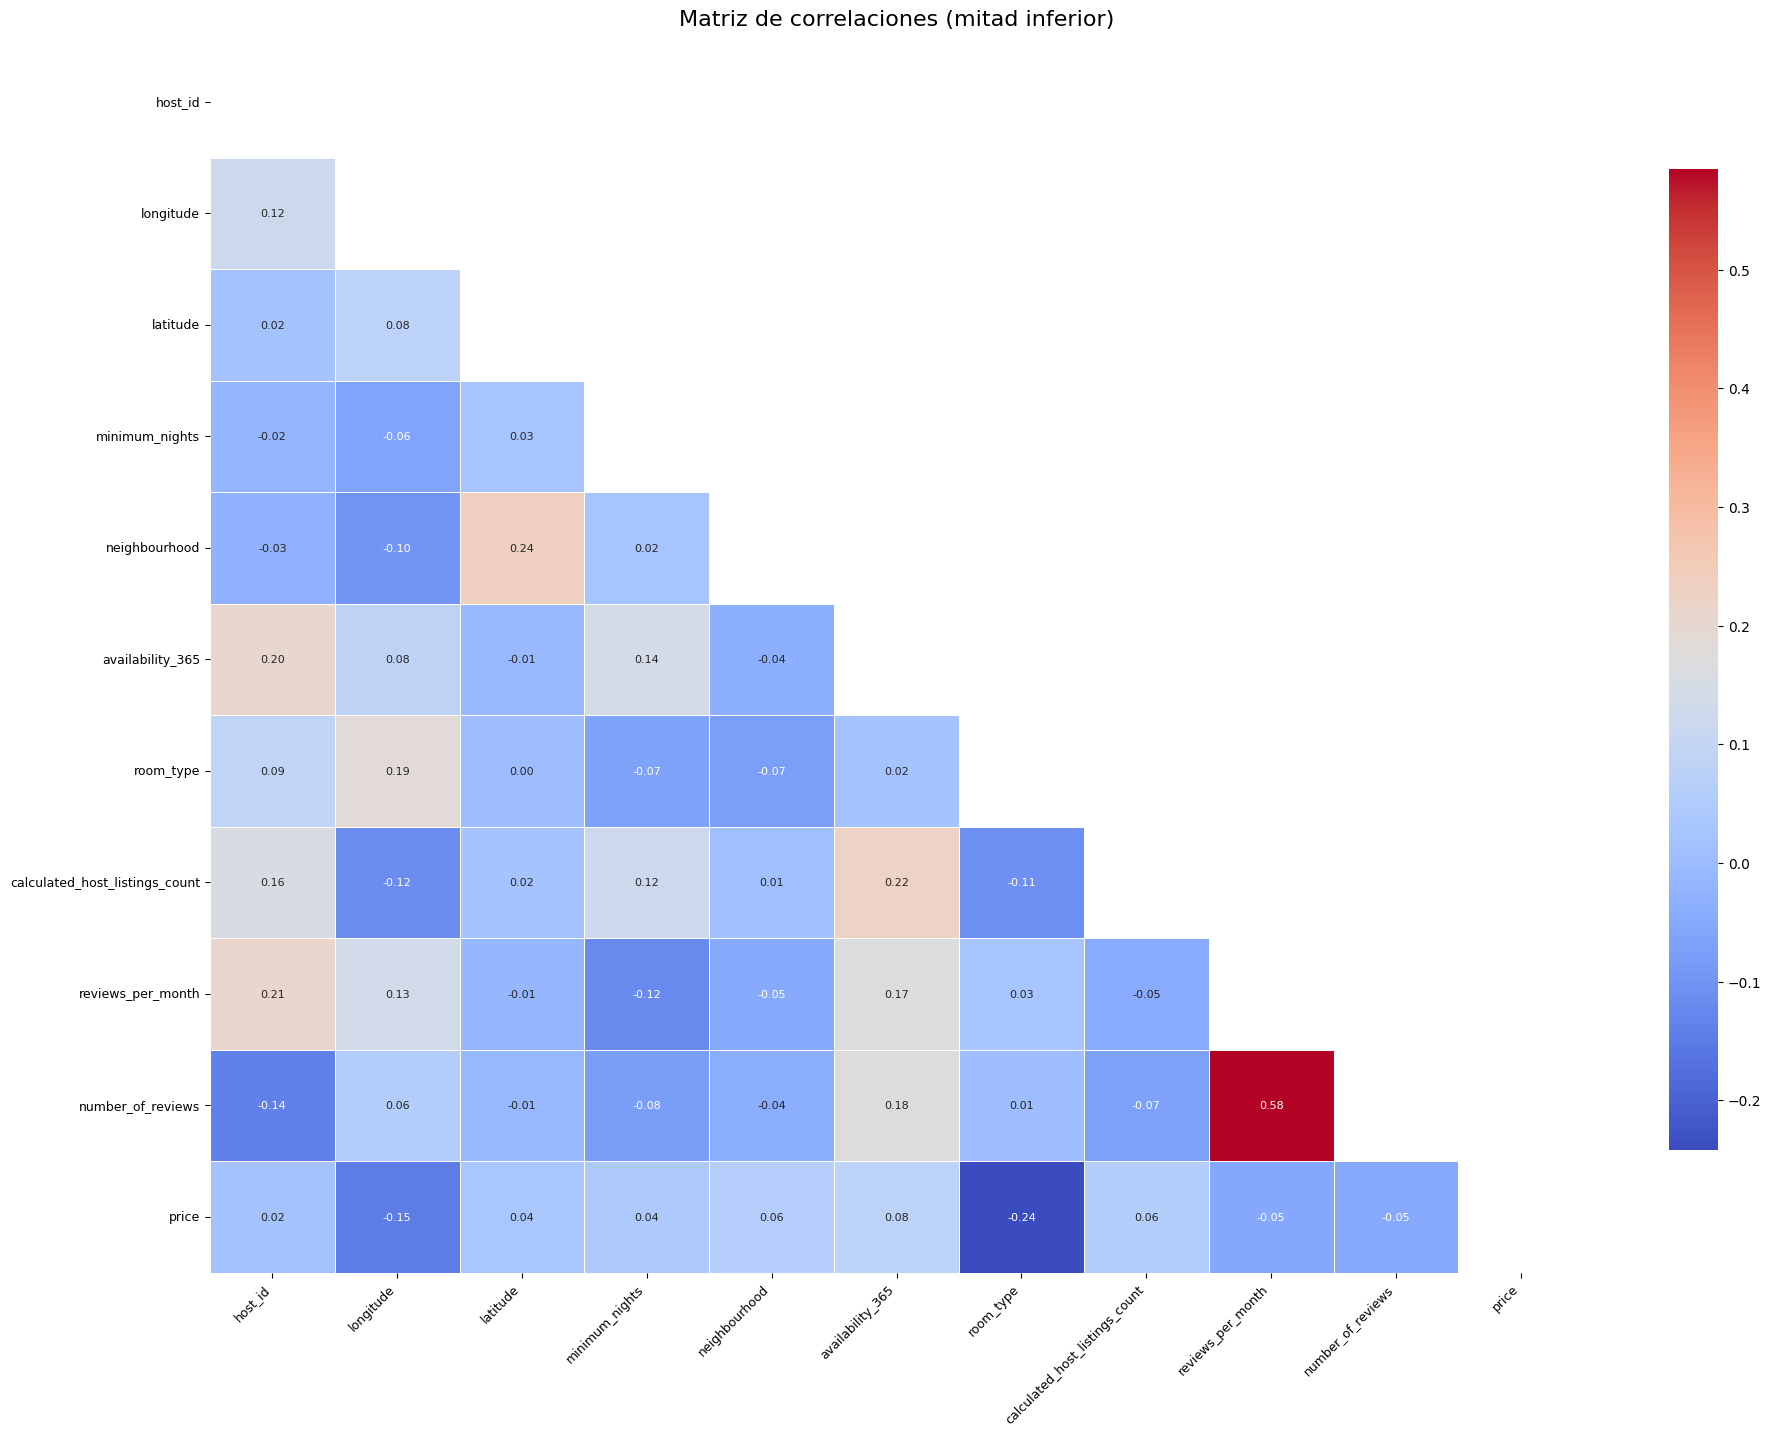

In [23]:
X_copy = X_train[features].copy()
X_copy['price'] = y_train
corr = X_copy.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(20, 15))
sns.heatmap(
    corr, mask=mask, cmap='coolwarm',
    annot=True, fmt=".2f", linewidths=.5,
    cbar_kws={"shrink": .8},
    annot_kws={"size": 8}
)
plt.title("Matriz de correlaciones (mitad inferior)", fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout(pad=3.0)
plt.show()

## Cross_validation

In [24]:
# Versión 1: Realizar cross_validation con todas las características que son candidatas
cv_results1 = cross_val_score(RandomForestRegressor(random_state=42,n_jobs=-1), X_train[features], y_train, cv=3, scoring='r2')

In [ ]:
cv_results1.mean()*1

np.float64(-0.14008291729959346)

In [26]:
# Versión 2: Realizar cross_validation con  las características que son candidatas sin las correlacionadas
cv_results2 = cross_val_score(RandomForestRegressor(random_state=42,n_jobs=-1), X_train[features].drop(['number_of_reviews'],axis=1), y_train, cv=3, scoring='r2')

In [27]:
cv_results2.mean()*1

np.float64(0.13252720018144296)